# Rolling P(GO) by Trial Condition — Right Direction

Applies the trained LR decoder in a sliding 100ms window from -300 to 600ms,
aligned to `go_cue`, `stop_cue`, and `first_relevant_saccade`.

**Conditions**: STOP, Error STOP, Slow GO, Fast GO, Slow CONT, Fast CONT  
**Direction**: Right (0°)  
**Session**: fi211025a | SSD level 2 decoder  
**Note**: GO trials aligned to stop_cue use go_cue + mean_ssd as proxy. Successful STOP trials have no saccade and are skipped for saccade alignment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle, joblib, sys

sys.path.insert(0, str(Path.cwd().parent))
from cell_analysis import Cell

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Config
SESSION_ID = 'fi211025a'
SSD_NUM = 2
DIRECTION = 0       # Right
WIN = 100           # Window size (ms)
STEP = 10           # Step size (ms)
T_RANGE = (-300, 600)
ALIGNMENTS = ['go_cue', 'stop_cue', 'first_relevant_saccade']

print('Setup complete')

Setup complete


In [2]:
# Load data, model, and normalization stats
base = Path.cwd().parents[1] / 'data'
cell_df = pd.read_pickle(base / 'unified_cell_trial_data' / 'msn_fiona_cell_trial_data.pkl')
session_data = cell_df[cell_df['trial_session'] == SESSION_ID]

lr_dict = joblib.load(base / 'decoder_models' / f'lr_decoder_{SESSION_ID}_ssd{SSD_NUM}_right.joblib')
lr_model = lr_dict['model']

with open(base / 'decoder_data' / f'decoder_data_{SESSION_ID}_ssd{SSD_NUM}.pkl', 'rb') as f:
    ds = pickle.load(f)['datasets'][DIRECTION]

cell_ids = ds['cell_ids']
neuron_mean, neuron_std = ds['neuron_stats']['mean'], ds['neuron_stats']['std']
mean_ssd = ds['mean_ssd']

print(f'Loaded: {len(cell_ids)} neurons, mean_ssd={mean_ssd:.0f}ms')

Loaded: 150 neurons, mean_ssd=108ms


In [3]:
# Create Cell objects per neuron and align spikes to all 3 alignment points
print('Aligning spikes for each neuron...')
aligned_cells = {}
for cid in cell_ids:
    c = Cell(session_data[session_data['cell_ID'] == cid],
             go_trials_stop_cue_alignment_bias=int(round(mean_ssd)))
    for al in ALIGNMENTS:
        c.align_spikes_to_event(al)
    aligned_cells[cid] = c

# Define trial conditions using Cell.filter_trials on a reference cell
ref = aligned_cells[cell_ids[0]]
trial_nums = {
    'STOP':       ref.filter_trials(trial_type='STOP', direction=DIRECTION, success_only=True)['trial_number'].unique(),
    'Error STOP': ref.filter_trials(trial_type='STOP', direction=DIRECTION, failed_only=True, success_only=False)['trial_number'].unique(),
    'Slow GO':    ref.filter_trials(trial_type='GO',   direction=DIRECTION, success_only=True, is_slow_go=True)['trial_number'].unique(),
    'Fast GO':    ref.filter_trials(trial_type='GO',   direction=DIRECTION, success_only=True, is_slow_go=False)['trial_number'].unique(),
    'Slow CONT':  ref.filter_trials(trial_type='CONT', direction=DIRECTION, success_only=True, is_slow_go=True)['trial_number'].unique(),
    'Fast CONT':  ref.filter_trials(trial_type='CONT', direction=DIRECTION, success_only=True, is_slow_go=False)['trial_number'].unique(),
}

for cond, tn in trial_nums.items():
    print(f'  {cond}: {len(tn)} trials')

Aligning spikes for each neuron...
  STOP: 18 trials
  Error STOP: 26 trials
  Slow GO: 53 trials
  Fast GO: 48 trials
  Slow CONT: 19 trials
  Fast CONT: 18 trials


In [4]:
# Pre-build spike lookup dict (avoids per-trial DataFrame queries)
print("Building spike lookup...")
spike_lookup = {}  # (cell_id, trial_number) -> {alignment: spikes_array}
for cid in cell_ids:
    cell = aligned_cells[cid]
    for _, row in cell.data.iterrows():
        tn = row['trial_number']
        spike_lookup[(cid, tn)] = {
            al: np.asarray(row[f'spikes_aligned_to_{al}'], dtype=float)
            for al in ALIGNMENTS
        }

# Diagnostic: verify trial numbers can be found
sample_cond = next(c for c, t in trial_nums.items() if len(t) > 0)
sample_tn = trial_nums[sample_cond][0]
n_found = sum(1 for cid in cell_ids if (cid, sample_tn) in spike_lookup)
print(f"  Check: trial {sample_tn} ({sample_cond}) in {n_found}/{len(cell_ids)} cells")
if n_found == 0:
    keys_sample = list(spike_lookup.keys())[:3]
    print(f"  ⚠ Type mismatch? ref type={type(sample_tn)}, dict key type={type(keys_sample[0][1])}")
    print(f"  ref value: {sample_tn!r}, dict key sample: {keys_sample[0][1]!r}")


def compute_rolling_pgo(trials, alignment):
    """Compute trial-averaged rolling P(GO) using pre-built spike lookup."""
    t_starts = np.arange(T_RANGE[0], T_RANGE[1] - WIN + STEP, STEP)
    t_centers = t_starts + WIN / 2
    n_bins = len(t_starts)
    hist_edges = np.arange(T_RANGE[0], T_RANGE[1] + 2, 1)
    bs = (t_starts - T_RANGE[0]).astype(int)
    be = bs + WIN

    pgo_all = []
    for tn in trials:
        # For saccade alignment, check validity before neuron loop
        if alignment == 'first_relevant_saccade':
            ref_entry = spike_lookup.get((cell_ids[0], tn))
            if ref_entry is None or len(ref_entry[alignment]) == 0:
                continue

        X = np.zeros((n_bins, len(cell_ids)))
        for ni, cid in enumerate(cell_ids):
            entry = spike_lookup.get((cid, tn))
            if entry is None:
                continue  # 0-fill for missing neuron
            spikes = entry[alignment]
            if len(spikes) == 0:
                continue
            h, _ = np.histogram(spikes, bins=hist_edges)
            cum = np.concatenate([[0], np.cumsum(h)])
            X[:, ni] = (cum[be] - cum[bs]) / (WIN / 1000)

        X_norm = (X - neuron_mean) / (neuron_std + 1e-10)
        pgo_all.append(lr_model.predict_proba(X_norm)[:, 1])

    if not pgo_all:
        return t_centers, np.full(n_bins, np.nan), np.full(n_bins, np.nan), 0
    arr = np.array(pgo_all)
    return t_centers, arr.mean(0), arr.std(0) / np.sqrt(len(arr)), len(arr)


# Compute all conditions x alignments
results = {}
for cond, tn in trial_nums.items():
    results[cond] = {}
    for al in ALIGNMENTS:
        if cond == 'STOP' and al == 'first_relevant_saccade':
            results[cond][al] = None
            print(f'  {cond} x {al}: skipped (no saccade)')
            continue
        t, m, s, n = compute_rolling_pgo(tn, al)
        results[cond][al] = {'t': t, 'mean': m, 'sem': s, 'n': n}
        print(f'  {cond} x {al}: {n} trials')

Building spike lookup...
  Check: trial 394 (STOP) in 58/150 cells
  STOP x go_cue: 18 trials
  STOP x stop_cue: 18 trials
  STOP x first_relevant_saccade: skipped (no saccade)
  Error STOP x go_cue: 26 trials
  Error STOP x stop_cue: 26 trials
  Error STOP x first_relevant_saccade: 15 trials
  Slow GO x go_cue: 53 trials
  Slow GO x stop_cue: 53 trials
  Slow GO x first_relevant_saccade: 43 trials
  Fast GO x go_cue: 48 trials
  Fast GO x stop_cue: 48 trials
  Fast GO x first_relevant_saccade: 36 trials
  Slow CONT x go_cue: 19 trials
  Slow CONT x stop_cue: 19 trials
  Slow CONT x first_relevant_saccade: 8 trials
  Fast CONT x go_cue: 18 trials
  Fast CONT x stop_cue: 18 trials
  Fast CONT x first_relevant_saccade: 15 trials


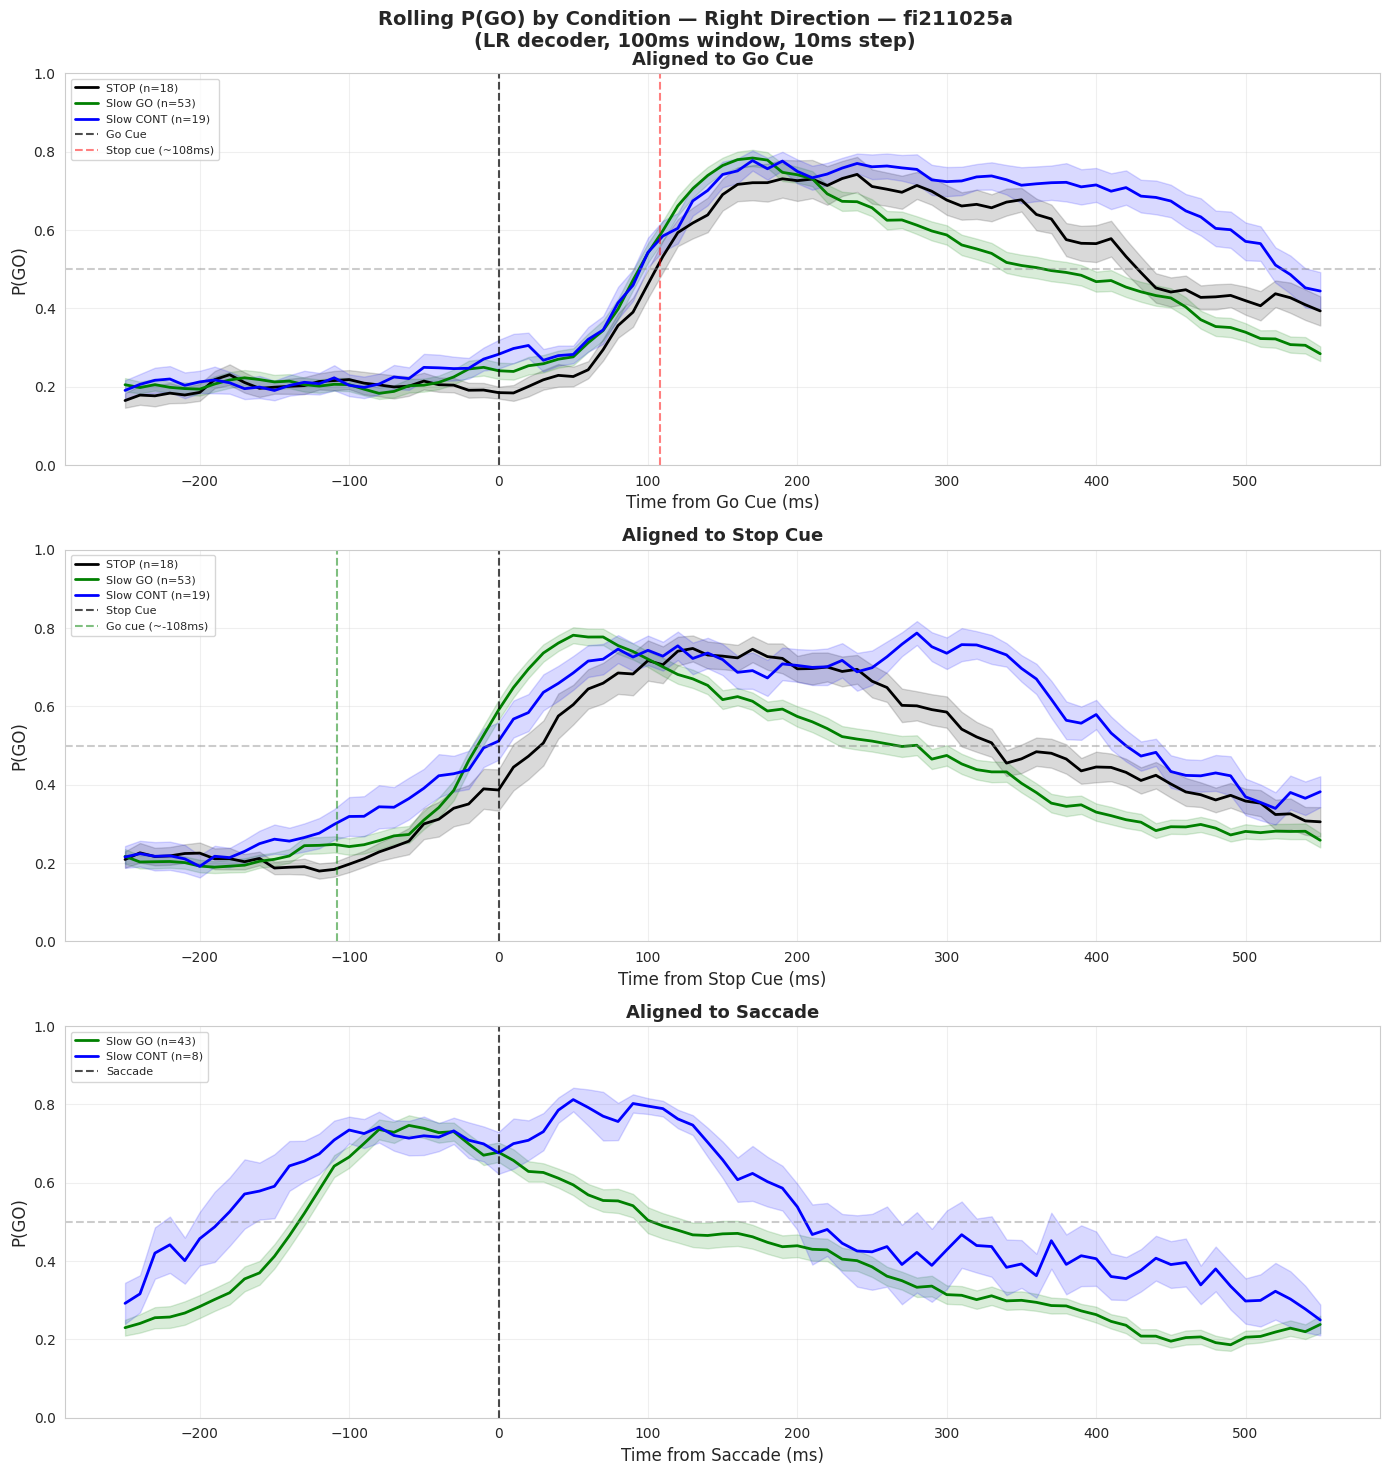

In [6]:
# Plot — colors from FlexiblePCA.PLOT_CONFIG (Right direction only)
COLORS = {
    'STOP': 'black',       'Error STOP': 'darkred',
    'Slow GO': 'green','Fast GO': 'magenta',
    'Slow CONT': 'blue',   'Fast CONT': 'darkblue',
}
AL_LABELS = {'go_cue': 'Go Cue', 'stop_cue': 'Stop Cue',
             'first_relevant_saccade': 'Saccade'}

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False, sharey=True)
"""
trial_nums = {
    'STOP':       ref.filter_trials(trial_type='STOP', direction=DIRECTION, success_only=True)['trial_number'].unique(),
    'Error STOP': ref.filter_trials(trial_type='STOP', direction=DIRECTION, failed_only=True, success_only=False)['trial_number'].unique(),
    'Slow GO':    ref.filter_trials(trial_type='GO',   direction=DIRECTION, success_only=True, is_slow_go=True)['trial_number'].unique(),
    'Fast GO':    ref.filter_trials(trial_type='GO',   direction=DIRECTION, success_only=True, is_slow_go=False)['trial_number'].unique(),
    'Slow CONT':  ref.filter_trials(trial_type='CONT', direction=DIRECTION, success_only=True, is_slow_go=True)['trial_number'].unique(),
    'Fast CONT':  ref.filter_trials(trial_type='CONT', direction=DIRECTION, success_only=True, is_slow_go=False)['trial_number'].unique(),
}
"""
for ai, al in enumerate(ALIGNMENTS):
    ax = axes[ai]
    for cond in trial_nums:
        if cond not in ['Slow GO', 'STOP', 'Slow CONT']:
            continue
        r = results[cond].get(al)
        if r is None:
            continue
        ax.plot(r['t'], r['mean'], label=f"{cond} (n={r['n']})",
                color=COLORS[cond], lw=2)
        ax.fill_between(r['t'], r['mean'] - r['sem'], r['mean'] + r['sem'],
                        color=COLORS[cond], alpha=0.15)

    ax.axhline(0.5, color='gray', ls='--', alpha=0.4)
    ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.7, label=AL_LABELS[al])
    if al == 'go_cue':
        ax.axvline(mean_ssd, color='red', ls='--', lw=1.5, alpha=0.5,
                   label=f'Stop cue (~{mean_ssd:.0f}ms)')
    elif al == 'stop_cue':
        ax.axvline(-mean_ssd, color='green', ls='--', lw=1.5, alpha=0.5,
                   label=f'Go cue (~-{mean_ssd:.0f}ms)')

    ax.set_xlabel(f'Time from {AL_LABELS[al]} (ms)', fontsize=12)
    ax.set_ylabel('P(GO)', fontsize=12)
    ax.set_title(f'Aligned to {AL_LABELS[al]}', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle(
    f'Rolling P(GO) by Condition — Right Direction — {SESSION_ID}\n'
    f'(LR decoder, {WIN}ms window, {STEP}ms step)',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  GO: 79 trials
  CONT: 23 trials
  Error STOP: 15 trials


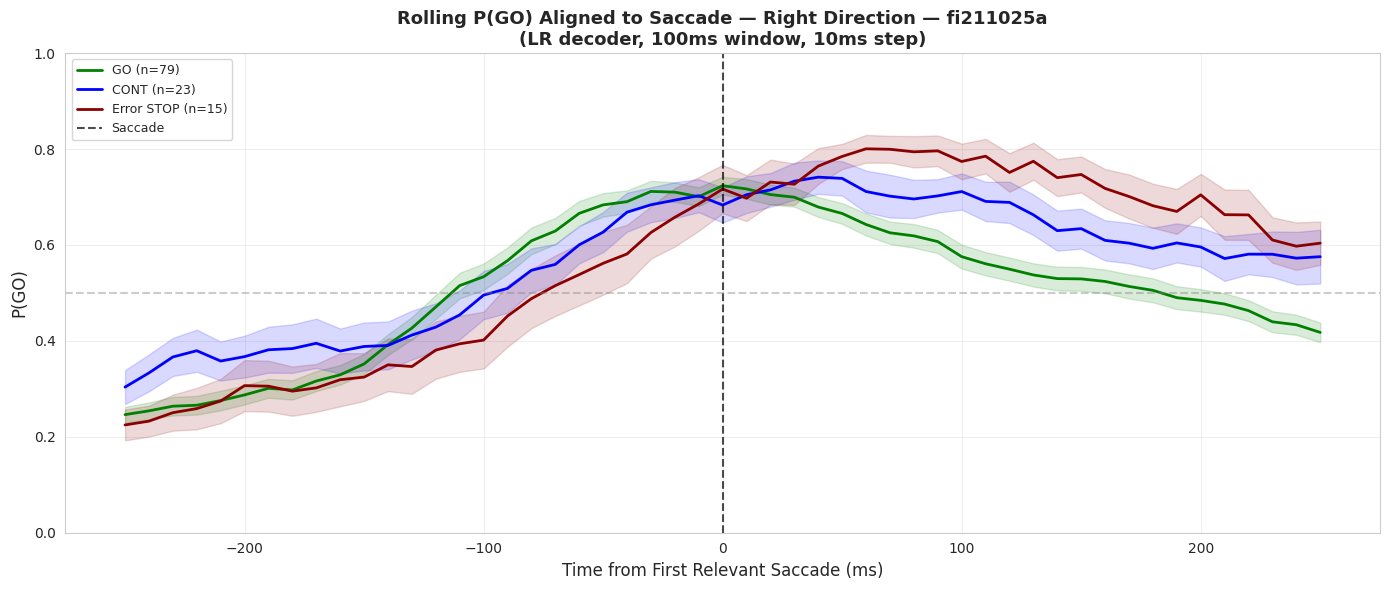

In [12]:
# Saccade-aligned analysis: GO, CONT, Error STOP from -300 to 300
SAC_RANGE = (-300, 300)

# Combine slow+fast into single GO and CONT conditions
go_all = np.concatenate([trial_nums['Slow GO'], trial_nums['Fast GO']])
cont_all = np.concatenate([trial_nums['Slow CONT'], trial_nums['Fast CONT']])

sac_conds = {
    'GO':         go_all,
    'CONT':       cont_all,
    'Error STOP': trial_nums['Error STOP'],
}

def compute_rolling_pgo_custom(trials, alignment, t_range):
    """Rolling P(GO) with custom time range."""
    t_starts = np.arange(t_range[0], t_range[1] - WIN + STEP, STEP)
    t_centers = t_starts + WIN / 2
    n_bins = len(t_starts)
    hist_edges = np.arange(t_range[0], t_range[1] + 2, 1)
    bs = (t_starts - t_range[0]).astype(int)
    be = bs + WIN

    pgo_all = []
    for tn in trials:
        entry0 = spike_lookup.get((cell_ids[0], tn))
        if entry0 is None or len(entry0[alignment]) == 0:
            continue
        X = np.zeros((n_bins, len(cell_ids)))
        for ni, cid in enumerate(cell_ids):
            entry = spike_lookup.get((cid, tn))
            if entry is None:
                continue
            spikes = entry[alignment]
            if len(spikes) == 0:
                continue
            h, _ = np.histogram(spikes, bins=hist_edges)
            cum = np.concatenate([[0], np.cumsum(h)])
            X[:, ni] = (cum[be] - cum[bs]) / (WIN / 1000)
        X_norm = (X - neuron_mean) / (neuron_std + 1e-10)
        pgo_all.append(lr_model.predict_proba(X_norm)[:, 1])

    if not pgo_all:
        return t_centers, np.full(n_bins, np.nan), np.full(n_bins, np.nan), 0
    arr = np.array(pgo_all)
    return t_centers, arr.mean(0), arr.std(0) / np.sqrt(len(arr)), len(arr)

sac_results = {}
for cond, tn in sac_conds.items():
    t, m, s, n = compute_rolling_pgo_custom(tn, 'first_relevant_saccade', SAC_RANGE)
    sac_results[cond] = {'t': t, 'mean': m, 'sem': s, 'n': n}
    print(f'  {cond}: {n} trials')

# Plot
SAC_COLORS = {'GO': 'green', 'CONT': 'blue', 'Error STOP': 'darkred'}
fig, ax = plt.subplots(figsize=(14, 6))
for cond, r in sac_results.items():
    if np.isnan(r['mean']).all():
        continue
    ax.plot(r['t'], r['mean'], label=f"{cond} (n={r['n']})",
            color=SAC_COLORS[cond], lw=2)
    ax.fill_between(r['t'], r['mean'] - r['sem'], r['mean'] + r['sem'],
                    color=SAC_COLORS[cond], alpha=0.15)

ax.axhline(0.5, color='gray', ls='--', alpha=0.4)
ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.7, label='Saccade')
ax.set_xlabel('Time from First Relevant Saccade (ms)', fontsize=12)
ax.set_ylabel('P(GO)', fontsize=12)
ax.set_ylim([0, 1])
ax.set_title(f'Rolling P(GO) Aligned to Saccade — Right Direction — {SESSION_ID}\n'
             f'(LR decoder, {WIN}ms window, {STEP}ms step)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()